In [1]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import glob
from scipy.io import readsav
from functools import partial
from matplotlib.colors import TwoSlopeNorm
import matplotlib.colors as mcolors

#数据准备
dir=r'D:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\RSM20240618T211711_0000_HA.fits'
rsm=fits.open(dir)
left_index=44
right_index=96
lam = rsm[1].header['CRVAL3'] + np.arange(rsm[1].header['NAXIS3']) * rsm[1].header['CDELT3']
lam=lam[left_index:right_index]#±1.5A

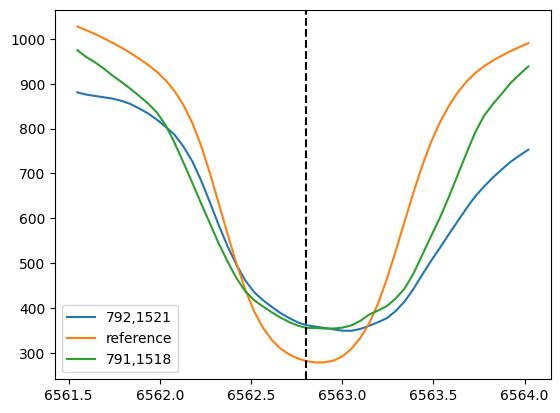

In [2]:
I0=rsm[1].data[left_index:right_index,797:826,1540:1569].mean(axis=(1,2))
plt.plot(lam,rsm[1].data[left_index:right_index,792,1521],label='792,1521')
plt.plot(lam,I0,label='reference')
plt.plot(lam,rsm[1].data[left_index:right_index,791,1518],label='791,1518')
plt.axvline(x=6562.8,linestyle='--',color='black')
plt.legend()

In [20]:
def double_cloud(lam,SL,SU,tau0L,tau0U,vL,vU,WL,WU,I0):
    lam0=6562.8
    c=299790
    tauL=tau0L*np.exp(-((lam-lam0-vL*lam0/c)**2)/WL**2)
    tauU=tau0U*np.exp(-((lam-lam0-vU*lam0/c)**2)/WU**2)
    I=I0*np.exp(-(tauL+tauU))+SL*(1-np.exp(-tauL))*np.exp(-tauU)+SU*(1-np.exp(-tauU))
    return I

SL=336.66,初值是684.17,范围是[0.00,20000.00], SU=847.48,初值是684.17,范围是[0.00,20000.00]
tau0L=1.15,初值是0.20,范围是[0.00,100.00], tau0U=10.27,初值是0.20,范围是[0.00,100.00]
vL=13.04,初值是20.00,范围是[-250.00,100.00], vU=-150.00,初值是-20.00,范围是[-150.00,100.00]
WL=0.90,初值是0.50,范围是[0.01,10.00], WU=1.49,初值是0.50,范围是[0.01,10.00]
拟合误差: 73.4475251927378


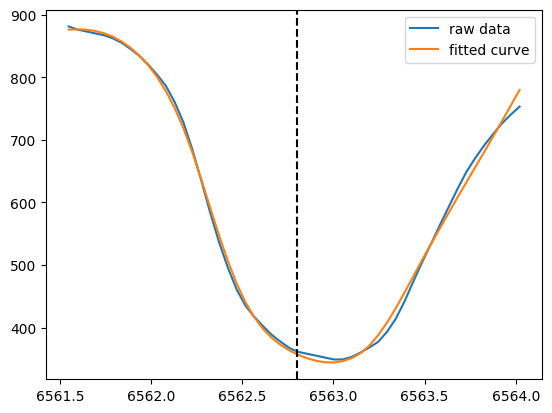

In [ ]:
I=rsm[1].data[left_index:right_index,792,1521]
#初值
paras2=np.zeros((3,8))
#第0列是SL_initial,min,max
paras2[0,0],paras2[1,0],paras2[2,0]=np.mean(I0),0,20000
#第1列是SU_initial,min,max
paras2[0,1],paras2[1,1],paras2[2,1]=np.mean(I0),0,20000
#第2列是\tau0L_initial,min,max
paras2[0,2],paras2[1,2],paras2[2,2]=0.2,0.001,100
#第3列是\tau0U_initial,min,max
paras2[0,3],paras2[1,3],paras2[2,3]=0.2,0.001,100
#第4列是vL_initial,min,max
paras2[0,4],paras2[1,4],paras2[2,4]=20,-250,100
#第5列是vU_initial,min,max
paras2[0,5],paras2[1,5],paras2[2,5]=-20,-150,100
#第6列是多普勒展宽WL
paras2[0,6],paras2[1,6],paras2[2,6]=0.5,0.01,10
#第7列是多普勒展宽WU
paras2[0,7],paras2[1,7],paras2[2,7]=0.5,0.01,10

#曲线拟合
double_cloud_par=partial(double_cloud,I0=I0)
popt2,pcov2=curve_fit(double_cloud_par,lam,I,p0=paras2[0,:],
                    bounds=(paras2[1,:],paras2[2,:]),maxfev=2000)

#输出拟合结果
SL_fit,SU_fit,tau0L_fit,tau0U_fit,vL_fit,vU_fit,WL_fit,WU_fit=popt2
print('SL={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], SU={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(SL_fit,paras2[0,0],paras2[1,0],paras2[2,0],SU_fit,paras2[0,1],paras2[1,1],paras2[2,1]))
print('tau0L={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], tau0U={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(tau0L_fit,paras2[0,2],paras2[1,2],paras2[2,2],tau0U_fit,paras2[0,3],paras2[1,3],paras2[2,3]))
print('vL={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], vU={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(vL_fit,paras2[0,4],paras2[1,4],paras2[2,4],vU_fit,paras2[0,5],paras2[1,5],paras2[2,5]))
print('WL={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}], WU={:.2f},初值是{:.2f},范围是[{:.2f},{:.2f}]'.format(WL_fit,paras2[0,6],paras2[1,6],paras2[2,6],WU_fit,paras2[0,7],paras2[1,7],paras2[2,7]))

#画图看拟合效果
plt.plot(lam,I,label='raw data')
plt.plot(lam,double_cloud_par(lam,*popt2),label='fitted curve')
plt.axvline(x=6562.8,linestyle='--',color='black')
plt.legend()
y_fit=double_cloud_par(lam,*popt2)
print('拟合误差:',np.sum((I-y_fit)**2)/len(I))

全局搜索结果: [ 8.29270226e+02  3.28228015e+02  3.04435452e+00  1.02906043e+00
 -1.50000000e+02  1.78344068e+01  2.02398194e+00  8.24854201e-01]
最优参数: [ 818.81760103  324.69324865    2.56291056    1.01105193 -149.99998636
   18.119741      2.11720754    0.82107683]
拟合误差: 94.34421628606175


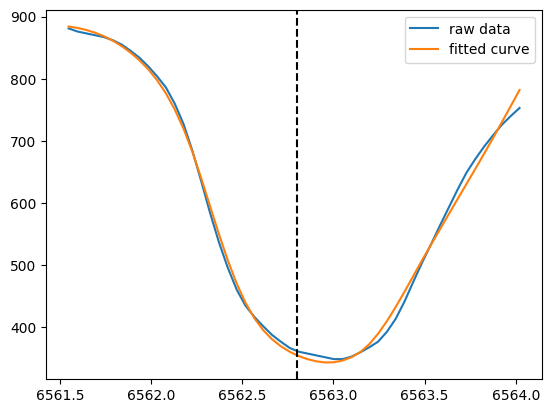

In [14]:
import numpy as np
from scipy.optimize import differential_evolution
from functools import partial

# 原来的模型函数 double_cloud(lam, SL, SU, tau0L, tau0U, vL, vU, WL, WU, I0)
# 这里用 partial 固定 I0
double_cloud_par = partial(double_cloud, I0=I0)

# 定义目标函数（残差平方和）
def objective(params, lam, I):
    model_vals = double_cloud_par(lam, *params)
    return np.sum((I - model_vals)**2/len(I))
    
# 定义参数边界（对应 curve_fit 的 bounds）
bounds = list(zip(paras2[1,:], paras2[2,:]))

# 全局优化
# Step 1: DE 全局搜索
result = differential_evolution(objective, bounds, args=(lam, I), maxiter=1000)
popt_global = result.x
print("全局搜索结果:", popt_global)
# Step 2: 用 DE 的结果作为初值，再局部精修
popt2, pcov2 = curve_fit(double_cloud_par, lam, I, p0=popt_global,
                         bounds=(paras2[1,:], paras2[2,:]), maxfev=5000)



# 输出拟合结果
SL_fit, SU_fit, tau0L_fit, tau0U_fit, vL_fit, vU_fit, WL_fit, WU_fit = popt2

print("最优参数:", popt2)
yfit=double_cloud_par(lam,*popt2)
print('拟合误差:',np.sum((I-yfit)**2)/len(I))

#画图看拟合效果
plt.plot(lam,I,label='raw data')
plt.plot(lam,double_cloud_par(lam,*popt2),label='fitted curve')
plt.axvline(x=6562.8,linestyle='--',color='black')
plt.legend()

DE finished, fun: 1630.4921984622742
LS finished, cost: 24.605211120491454 success: True
SL=879.204, SU=810.562, Icont=343.875
tau0L=4.4086, tau0U=2.0258
vL=-58.231 km/s, vU=60.883 km/s
WL=25.7823 km/s, WU=23.1072 km/s


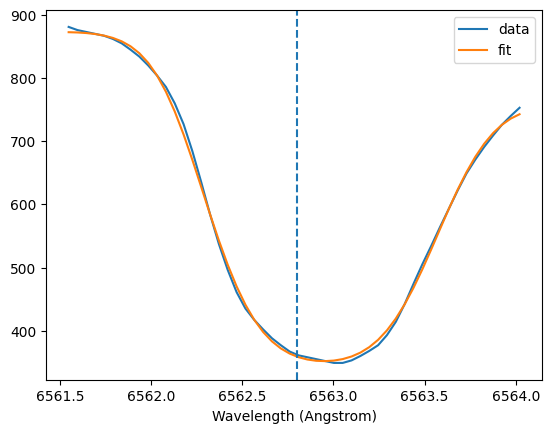

Approx param std: [4.30062376e+00 1.06573439e+02 8.34721607e+01 1.13718032e+03
 1.37427921e+00 1.61028346e+01 1.00125143e+02 1.25710841e+04
 1.23486832e+02]
Correlation matrix:
 [[ 1.          0.99650716 -0.9999097   0.99655722  0.99967441  0.99664601
  -0.99883961 -0.99648463 -0.99771821]
 [ 0.99650716  1.         -0.99719819  0.99999807  0.99785562  0.99998618
  -0.99328517 -0.99999969 -0.99925113]
 [-0.9999097  -0.99719819  1.         -0.9972479  -0.99991953 -0.99733576
   0.99816212  0.99717584  0.99836817]
 [ 0.99655722  0.99999807 -0.9972479   1.          0.99790472  0.99999453
  -0.99333583 -0.99999622 -0.99929641]
 [ 0.99967441  0.99785562 -0.99991953  0.99790472  1.          0.997991
  -0.99749728 -0.99783359 -0.99896067]
 [ 0.99664601  0.99998618 -0.99733576  0.99999453  0.997991    1.
  -0.99342634 -0.99998181 -0.99937326]
 [-0.99883961 -0.99328517  0.99816212 -0.99333583 -0.99749728 -0.99342634
   1.          0.99326231  0.9945781 ]
 [-0.99648463 -0.99999969  0.99717584 -0.

In [23]:
import numpy as np
from functools import partial
from scipy.optimize import differential_evolution, least_squares
import matplotlib.pyplot as plt

# 你的观测数据：lam, I （注意：I0名字冲突，建议把 continuum 叫 Icont）
# lam: array of wavelengths in Angstroms
# I: data flux array

lam0 = 6562.8
c_km = 299792.458  # km/s

# 1) 把 wavelength -> velocity (km/s) relative to lam0
vel = (lam - lam0) / lam0 * c_km  # array in km/s
# 归一化 vel 到量纲合理的量（这里不强制，但保持 vel 的尺度是几百）
# 可以进一步标准化： vel = (vel - vel.mean())/vel.std()  # 如果你愿意

# 2) 定义重新参数化的模型：参数为 [log_tau0L, log_tau0U, vL, vU, log_WL, log_WU, SL, SU, Icont]
def double_cloud_vel(params, vel):
    # params: [ltauL, ltauU, vL, vU, lWl, lWu, SL, SU, Icont]
    ltauL, ltauU, vL, vU, lWl, lWu, SL, SU, Icont = params
    tau0L = np.exp(ltauL)
    tau0U = np.exp(ltauU)
    WL = np.exp(lWl)
    WU = np.exp(lWu)
    # note: WL/WU are in km/s units because vel is in km/s
    # Gaussian: tau = tau0 * exp(-((vel - v)^2) / WL^2 )
    tauL = tau0L * np.exp(-((vel - vL)**2) / (WL**2))
    tauU = tau0U * np.exp(-((vel - vU)**2) / (WU**2))
    I = Icont * np.exp(-(tauL + tauU)) + SL * (1 - np.exp(-tauL)) * np.exp(-tauU) + SU * (1 - np.exp(-tauU))
    return I

# 3) define residuals for least_squares
def residuals(params, vel, I):
    return double_cloud_vel(params, vel) - I

# 4) bounds in transformed space (ltau, lW are logs)
# choose reasonable bounds: tau in [1e-3, 1e2] -> log range [-6.9, 4.6]
# W in [0.1, 200] km/s -> log range [-2.3, 5.3]  (adjust to your instrument)
# v in [-400, 400] km/s (or tighter)
# SL, SU, Icont based on data scale
Imean = np.mean(I)
lb = [
    np.log(1e-3), np.log(1e-3),   # ltauL, ltauU
    -300.0, -300.0,               # vL, vU
    np.log(0.05), np.log(0.05),   # lWl, lWu
    0.0, 0.0,                      # SL, SU  (lower)
    0.0                            # Icont lower
]
ub = [
    np.log(1e2), np.log(1e2),
    300.0, 300.0,
    np.log(200.0), np.log(200.0),
    Imean*10, Imean*10,
    Imean*10
]

bounds = list(zip(lb, ub))

# 5) differential_evolution on sum of squares (global)
def ssq_obj(x):
    # differential_evolution gives x in original space; ensure shape consistent
    res = residuals(x, vel, I)
    return np.sum(res**2)

# provide DE with population-based bounds (we can pass bounds directly)
result_de = differential_evolution(ssq_obj, bounds, maxiter=1000, popsize=15, tol=1e-6)
x_de = result_de.x
print("DE finished, fun:", result_de.fun)

# 6) refine with least_squares using robust loss and x_scale
lsq = least_squares(residuals, x_de, args=(vel, I),
                    bounds=(np.array(lb), np.array(ub)),
                    loss='soft_l1', f_scale=0.1,
                    x_scale='jac', max_nfev=2000)

x_opt = lsq.x
print("LS finished, cost:", lsq.cost, "success:", lsq.success)

# 7) unpack and print in natural units
ltauL, ltauU, vL, vU, lWl, lWu, SL, SU, Icont = x_opt
tau0L = np.exp(ltauL); tau0U = np.exp(ltauU)
WL = np.exp(lWl); WU = np.exp(lWu)
print(f"SL={SL:.3f}, SU={SU:.3f}, Icont={Icont:.3f}")
print(f"tau0L={tau0L:.4f}, tau0U={tau0U:.4f}")
print(f"vL={vL:.3f} km/s, vU={vU:.3f} km/s")
print(f"WL={WL:.4f} km/s, WU={WU:.4f} km/s")

# 8) plot
y_fit = double_cloud_vel(x_opt, vel)
plt.figure()
plt.plot(lam, I, label='data')
plt.plot(lam, y_fit, label='fit')
plt.axvline(lam0, linestyle='--')
plt.legend()
plt.xlabel('Wavelength (Angstrom)')
plt.show()

# 9) 诊断：参数相关性（雅可比近似）
J = lsq.jac  # jacobian at solution (m x n)
# compute covariance approximation: cov = inv(J^T J) * residual_variance
try:
    JTJ = J.T.dot(J)
    cov = np.linalg.inv(JTJ) * 2*lsq.cost / (len(I) - len(x_opt))
    corr = cov / np.sqrt(np.outer(np.diag(cov), np.diag(cov)))
    print("Approx param std:", np.sqrt(np.abs(np.diag(cov))))
    print("Correlation matrix:\n", corr)
except np.linalg.LinAlgError:
    print("Warning: JTJ singular - parameters likely non-identifiable or redundant.")


DE finished, fun: 1630.5811090872705
LS finished, cost: 24.605211110552776 success: True
SL=879.204, SU=810.557, Icont=343.875
tau0L=4.4086, tau0U=2.0259
vL=-58.231 km/s, vU=60.884 km/s
WL=25.7823 km/s, WU=23.1072 km/s


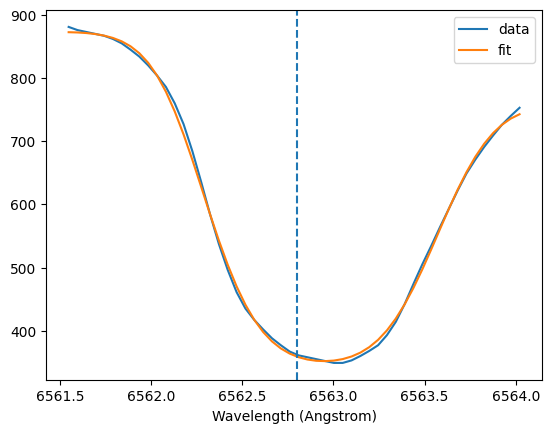

Approx param std: [4.30091489e+00 1.06580624e+02 8.34777990e+01 1.13728645e+03
 1.37438523e+00 1.61044004e+01 1.00134825e+02 1.25711308e+04
 1.23497937e+02]
Correlation matrix:
 [[ 1.          0.99650745 -0.99990971  0.9965576   0.99967444  0.9966465
  -0.99883988 -0.99648488 -0.99771833]
 [ 0.99650745  1.         -0.99719844  0.99999806  0.99785586  0.99998615
  -0.99328611 -0.99999969 -0.99925124]
 [-0.99990971 -0.99719844  1.         -0.99724824 -0.99991953 -0.9973362
   0.99816251  0.99717605  0.99836824]
 [ 0.9965576   0.99999806 -0.99724824  1.          0.99790505  0.99999452
  -0.99333685 -0.99999621 -0.9992966 ]
 [ 0.99967444  0.99785586 -0.99991953  0.99790505  1.          0.99799144
  -0.99749777 -0.99783379 -0.99896074]
 [ 0.9966465   0.99998615 -0.9973362   0.99999452  0.99799144  1.
  -0.99342747 -0.99998176 -0.99937356]
 [-0.99883988 -0.99328611  0.99816251 -0.99333685 -0.99749777 -0.99342747
   1.          0.9932632   0.99457885]
 [-0.99648488 -0.99999969  0.99717605 -0.

In [31]:
import numpy as np
from functools import partial
from scipy.optimize import differential_evolution, least_squares
import matplotlib.pyplot as plt

# 你的观测数据：lam, I （注意：I0名字冲突，建议把 continuum 叫 Icont）
# lam: array of wavelengths in Angstroms
# I: data flux array

lam0 = 6562.8
c_km = 299792.458  # km/s

# 1) 把 wavelength -> velocity (km/s) relative to lam0
vel = (lam - lam0) / lam0 * c_km  # array in km/s
# 归一化 vel 到量纲合理的量（这里不强制，但保持 vel 的尺度是几百）
# 可以进一步标准化： vel = (vel - vel.mean())/vel.std()  # 如果你愿意

# 2) 定义重新参数化的模型：参数为 [log_tau0L, log_tau0U, vL, vU, log_WL, log_WU, SL, SU, Icont]
def double_cloud_vel(params, vel):
    # params: [ltauL, ltauU, vL, vU, lWl, lWu, SL, SU, Icont]
    ltauL, ltauU, vL, vU, lWl, lWu, SL, SU, Icont = params
    tau0L = np.exp(ltauL)
    tau0U = np.exp(ltauU)
    WL = np.exp(lWl)
    WU = np.exp(lWu)
    # note: WL/WU are in km/s units because vel is in km/s
    # Gaussian: tau = tau0 * exp(-((vel - v)^2) / WL^2 )
    tauL = tau0L * np.exp(-((vel - vL)**2) / (WL**2))
    tauU = tau0U * np.exp(-((vel - vU)**2) / (WU**2))
    I = Icont * np.exp(-(tauL + tauU)) + SL * (1 - np.exp(-tauL)) * np.exp(-tauU) + SU * (1 - np.exp(-tauU))
    return I

# 3) define residuals for least_squares
def residuals(params, vel, I):
    return double_cloud_vel(params, vel) - I

# 4) bounds in transformed space (ltau, lW are logs)
# choose reasonable bounds: tau in [1e-3, 1e2] -> log range [-6.9, 4.6]
# W in [0.1, 200] km/s -> log range [-2.3, 5.3]  (adjust to your instrument)
# v in [-400, 400] km/s (or tighter)
# SL, SU, Icont based on data scale
Imean = np.mean(I)
lb = [
    np.log(1e-3), np.log(1e-3),   # ltauL, ltauU
    -300.0, -300.0,               # vL, vU
    np.log(0.05), np.log(0.05),   # lWl, lWu
    0.0, 0.0,                      # SL, SU  (lower)
    0.0                            # Icont lower
]
ub = [
    np.log(1e2), np.log(1e2),
    300.0, 300.0,
    np.log(200.0), np.log(200.0),
    Imean*10, Imean*10,
    Imean*10
]

bounds = list(zip(lb, ub))

# 5) differential_evolution on sum of squares (global)
def ssq_obj(x):
    # differential_evolution gives x in original space; ensure shape consistent
    res = residuals(x, vel, I)
    return np.sum(res**2)

# provide DE with population-based bounds (we can pass bounds directly)
result_de = differential_evolution(ssq_obj, bounds, maxiter=1000, popsize=15, tol=1e-6)
x_de = result_de.x
print("DE finished, fun:", result_de.fun)

# 6) refine with least_squares using robust loss and x_scale
lsq = least_squares(residuals, x_de, args=(vel, I),
                    bounds=(np.array(lb), np.array(ub)),
                    loss='soft_l1', f_scale=0.1,
                    x_scale='jac', max_nfev=2000)

x_opt = lsq.x
print("LS finished, cost:", lsq.cost, "success:", lsq.success)

# 7) unpack and print in natural units
ltauL, ltauU, vL, vU, lWl, lWu, SL, SU, Icont = x_opt
tau0L = np.exp(ltauL); tau0U = np.exp(ltauU)
WL = np.exp(lWl); WU = np.exp(lWu)
print(f"SL={SL:.3f}, SU={SU:.3f}, Icont={Icont:.3f}")
print(f"tau0L={tau0L:.4f}, tau0U={tau0U:.4f}")
print(f"vL={vL:.3f} km/s, vU={vU:.3f} km/s")
print(f"WL={WL:.4f} km/s, WU={WU:.4f} km/s")

# 8) plot
y_fit = double_cloud_vel(x_opt, vel)
plt.figure()
plt.plot(lam, I, label='data')
plt.plot(lam, y_fit, label='fit')
plt.axvline(lam0, linestyle='--')
plt.legend()
plt.xlabel('Wavelength (Angstrom)')
plt.show()

# 9) 诊断：参数相关性（雅可比近似）
J = lsq.jac  # jacobian at solution (m x n)
# compute covariance approximation: cov = inv(J^T J) * residual_variance
try:
    JTJ = J.T.dot(J)
    cov = np.linalg.inv(JTJ) * 2*lsq.cost / (len(I) - len(x_opt))
    corr = cov / np.sqrt(np.outer(np.diag(cov), np.diag(cov)))
    print("Approx param std:", np.sqrt(np.abs(np.diag(cov))))
    print("Correlation matrix:\n", corr)
except np.linalg.LinAlgError:
    print("Warning: JTJ singular - parameters likely non-identifiable or redundant.")


DE finished, SSE: 3753.9220710221202
SL=297.654, SU=779.044
tau0L=1.0827, tau0U=23.6957
vL=15.434 km/s, vU=-300.000 km/s
WL=36.6056 km/s, WU=133.8027 km/s


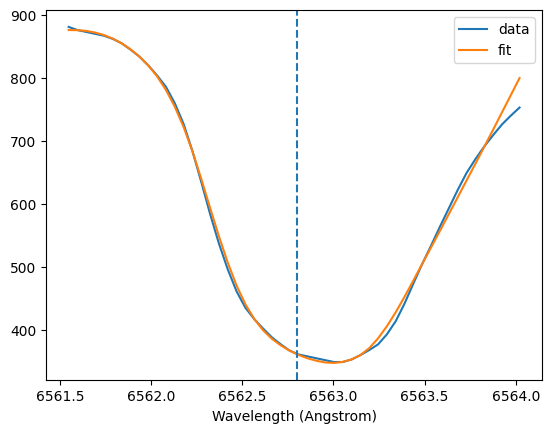

In [45]:
import numpy as np
from functools import partial
from scipy.optimize import differential_evolution, least_squares
import matplotlib.pyplot as plt

lam0 = 6562.8
c_km = 299792.458  # 光速 (km/s)

# 1. wavelength → velocity
vel = (lam - lam0) / lam0 * c_km  # km/s

# ===== 固定的背景连续谱强度 =====
Icont = I0  # 你之前定义的背景值，例如在平静区域测得的平均值

# 2. 双云模型（去掉 Icont 作为拟合变量）
# 参数: [ltauL, ltauU, vL, vU, lWl, lWu, SL, SU]
def double_cloud_vel(params, vel, Icont):
    ltauL, ltauU, vL, vU, lWl, lWu, SL, SU = params
    tau0L = np.exp(ltauL)
    tau0U = np.exp(ltauU)
    WL = np.exp(lWl)
    WU = np.exp(lWu)
    
    tauL = tau0L * np.exp(-((vel - vL)**2) / (WL**2))
    tauU = tau0U * np.exp(-((vel - vU)**2) / (WU**2))
    
    I = Icont * np.exp(-(tauL + tauU)) \
        + SL * (1 - np.exp(-tauL)) * np.exp(-tauU) \
        + SU * (1 - np.exp(-tauU))
    return I

# 3. 残差函数
def residuals(params, vel, I, Icont):
    return double_cloud_vel(params, vel, Icont) - I

# 4. 参数范围
# log tau: [1e-3, 1e2]
# W: [0.05, 200] km/s
Imean = np.mean(I)
lb = [
    np.log(1e-3), np.log(1e-3),   # ltauL, ltauU
    -300.0, -300.0,               # vL, vU
    np.log(0.05), np.log(0.05),   # lWl, lWu
    0.0, 0.0                       # SL, SU
]
ub = [
    np.log(1e2), np.log(1e2),
    300.0, 300.0,
    np.log(200.0), np.log(200.0),
    Imean*10, Imean*10
]
bounds = list(zip(lb, ub))

# 5. DE全局搜索
def ssq_obj(x):
    res = residuals(x, vel, I, Icont)
    return np.sum(res**2)

result_de = differential_evolution(ssq_obj, bounds, maxiter=800, popsize=15, tol=1e-6)
x_de = result_de.x
print("DE finished, SSE:", result_de.fun)

# 6. 局部精炼
lsq = least_squares(residuals, x_de, args=(vel, I, Icont),
                    bounds=(np.array(lb), np.array(ub)),
                    loss='soft_l1', f_scale=0.1,
                    x_scale='jac', max_nfev=2000)
x_opt = lsq.x

# 7. 拆解结果
ltauL, ltauU, vL, vU, lWl, lWu, SL, SU = x_opt
tau0L = np.exp(ltauL); tau0U = np.exp(ltauU)
WL = np.exp(lWl); WU = np.exp(lWu)


print(f"SL={SL:.3f}, SU={SU:.3f}")
print(f"tau0L={tau0L:.4f}, tau0U={tau0U:.4f}")
print(f"vL={vL:.3f} km/s, vU={vU:.3f} km/s")
print(f"WL={WL:.4f} km/s, WU={WU:.4f} km/s")

# 8. 作图
y_fit = double_cloud_vel(x_opt, vel, Icont)
plt.figure()
plt.plot(lam, I, label='data')
plt.plot(lam, y_fit, label='fit')
plt.axvline(lam0, linestyle='--')
plt.legend()
plt.xlabel('Wavelength (Angstrom)')
plt.show()


In [44]:
a=np.zeros((24,2))
b=np.zeros((24,2))
c=np.column_stack((a,b))
print(c.shape)

(24, 4)


DE finished, SSE: 3293.0603083102324
SL=358.026, SU=5866.346
tau0L=1.6055, tau0U=0.0474
vL=-1.655 km/s, vU=-36.131 km/s
WL=48.8232 km/s, WU=21.5685 km/s


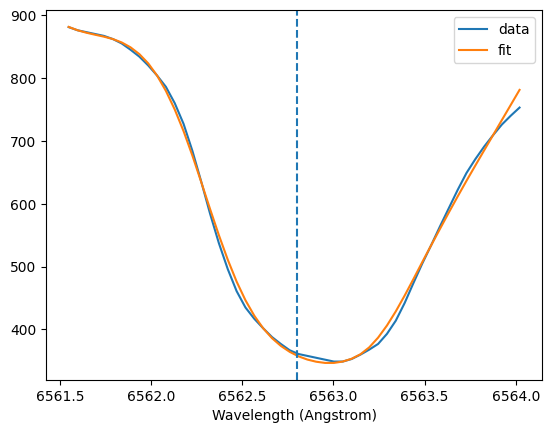

In [ ]:
import numpy as np
from functools import partial
from scipy.optimize import differential_evolution, least_squares
import matplotlib.pyplot as plt

lam0 = 6562.8
c_km = 299792.458  # 光速 (km/s)

# 1. wavelength → velocity
vel = (lam - lam0) / lam0 * c_km  # km/s

# ===== 固定的背景连续谱强度 =====
Icont = I0  # 你之前定义的背景值，例如在平静区域测得的平均值

# 2. 双云模型（去掉 Icont 作为拟合变量）
# 参数: [ltauL, ltauU, vL, vU, lWl, lWu, SL, SU]
def double_cloud_vel(params, vel, Icont):
    ltauL, ltauU, vL, vU, lWl, lWu, SL, SU = params
    tau0L = np.exp(ltauL)
    tau0U = np.exp(ltauU)
    WL = np.exp(lWl)
    WU = np.exp(lWu)
    
    tauL = tau0L * np.exp(-((vel - vL)**2) / (WL**2))
    tauU = tau0U * np.exp(-((vel - vU)**2) / (WU**2))
    
    I = Icont * np.exp(-(tauL + tauU)) \
        + SL * (1 - np.exp(-tauL)) * np.exp(-tauU) \
        + SU * (1 - np.exp(-tauU))
    return I

# 3. 残差函数
def residuals(params, vel, I, Icont):
    return double_cloud_vel(params, vel, Icont) - I

# 4. 参数范围
# log tau: [1e-3, 1e2]
# W: [0.05, 200] km/s
Imean = np.mean(I)
lb = [
    np.log(1e-3), np.log(1e-3),   # ltauL, ltauU
    -200.0, -200.0,               # vL, vU
    np.log(0.05), np.log(0.05),   # lWl, lWu
    0.0, 0.0                       # SL, SU
]
ub = [
    np.log(1e2), np.log(1e2),
    200.0, 200.0,
    np.log(200.0), np.log(200.0),
    Imean*10, Imean*10
]
bounds = list(zip(lb, ub))

# 5. DE全局搜索
def ssq_obj(x):
    res = residuals(x, vel, I, Icont)
    return np.sum(res**2)

result_de = differential_evolution(ssq_obj, bounds, maxiter=800, popsize=15, tol=1e-6)
x_de = result_de.x
print("DE finished, SSE:", result_de.fun)

# 6. 局部精炼
lsq = least_squares(residuals, x_de, args=(vel, I, Icont),
                    bounds=(np.array(lb), np.array(ub)),
                    loss='soft_l1', f_scale=0.1,
                    x_scale='jac', max_nfev=2000)
x_opt = lsq.x

# 7. 拆解结果
ltauL, ltauU, vL, vU, lWl, lWu, SL, SU = x_opt
tau0L = np.exp(ltauL); tau0U = np.exp(ltauU)
WL = np.exp(lWl); WU = np.exp(lWu)


print(f"SL={SL:.3f}, SU={SU:.3f}")
print(f"tau0L={tau0L:.4f}, tau0U={tau0U:.4f}")
print(f"vL={vL:.3f} km/s, vU={vU:.3f} km/s")
print(f"WL={WL:.4f} km/s, WU={WU:.4f} km/s")

# 8. 作图
y_fit = double_cloud_vel(x_opt, vel, Icont)
plt.figure()
plt.plot(lam, I, label='data')
plt.plot(lam, y_fit, label='fit')
plt.axvline(lam0, linestyle='--')
plt.legend()
plt.xlabel('Wavelength (Angstrom)')
plt.show()


No constraints given.
New best for swarm at iteration 1: [ 1.93433052e+03  1.13151820e+03  1.00000000e-03  1.00000000e+02
  1.00000000e+02 -1.31301595e+02  1.00000000e-02  3.74464935e-01] 1280109.8586714342
New best for swarm at iteration 1: [ 2.77545431e+02  8.52221682e+02  5.33386847e+01  4.58365229e+01
 -1.25037504e+02  5.93135758e+01  1.00000000e-02  1.00000000e-02] 1280109.8266516419
New best for swarm at iteration 1: [5.79165435e+02 4.75476754e+02 1.00000000e-03 1.00000000e-03
 7.47137497e+01 1.00000000e+02 1.00000000e-02 9.86565406e+00] 1275382.893416817
Best after iteration 1: [5.79165435e+02 4.75476754e+02 1.00000000e-03 1.00000000e-03
 7.47137497e+01 1.00000000e+02 1.00000000e-02 9.86565406e+00] 1275382.893416817
New best for swarm at iteration 2: [1.64686570e+03 0.00000000e+00 6.76151963e+01 1.00000000e-03
 1.00000000e+02 9.29712022e+01 1.00000000e-02 1.00000000e+01] 1270717.3258890188
Best after iteration 2: [1.64686570e+03 0.00000000e+00 6.76151963e+01 1.00000000e-03
 1.00

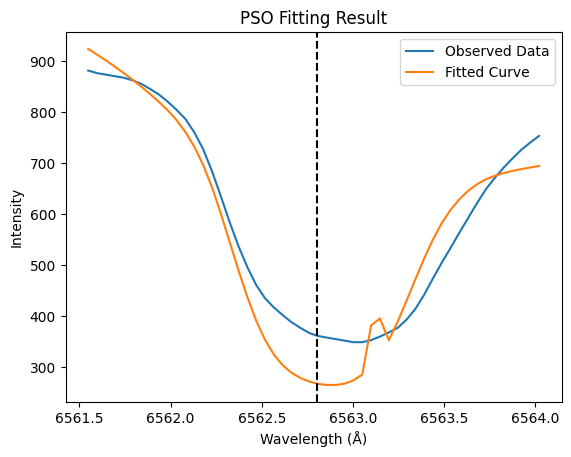

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from pyswarm import pso

# 双云模型
def double_cloud(lam, SL, SU, tau0L, tau0U, vL, vU, WL, WU, Icont):
    lam0 = 6562.8
    c = 299790  # km/s
    tauL = tau0L * np.exp(-((lam - lam0 - vL * lam0 / c)**2) / WL**2)
    tauU = tau0U * np.exp(-((lam - lam0 - vU * lam0 / c)**2) / WU**2)
    I = Icont * np.exp(-(tauL + tauU)) + SL * (1 - np.exp(-tauL)) * np.exp(-tauU) + SU * (1 - np.exp(-tauU))
    return I

# 残差函数，用于 PSO 计算目标值（拟合误差）
def residuals(params, lam, I, Icont):
    SL, SU, tau0L, tau0U, vL, vU, WL, WU = params
    I_fit = double_cloud(lam, SL, SU, tau0L, tau0U, vL, vU, WL, WU, Icont)
    return np.sum((I - I_fit)**2)  # 残差平方和

# 使用 PSO 进行参数优化
def optimize_with_pso(lam, I, Icont):
    # 参数范围: (SL, SU, tau0L, tau0U, vL, vU, WL, WU)
    lb = [0, 0, 0.001, 0.001, -250, -150, 0.01, 0.01]  # 参数下界
    ub = [2000, 2000, 100, 100, 100, 100, 10, 10]     # 参数上界

    # 调用 pso 函数进行优化
    best_params, _ = pso(residuals, lb, ub, args=(lam, I, Icont), swarmsize=50, maxiter=200, debug=True)

    # 返回最优参数
    return best_params

# 测试：优化过程

lam = rsm[1].header['CRVAL3'] + np.arange(rsm[1].header['NAXIS3']) * rsm[1].header['CDELT3']
lam=lam[left_index:right_index]#±1.5A
I=rsm[1].data[left_index:right_index,792,1521]
Icont=rsm[1].data[left_index:right_index,797:826,1540:1569].mean(axis=(1,2))
# 使用 PSO 优化
best_params = optimize_with_pso(lam, I, Icont)

# 输出拟合结果
SL_fit, SU_fit, tau0L_fit, tau0U_fit, vL_fit, vU_fit, WL_fit, WU_fit = best_params
print(f"优化结果: SL={SL_fit}, SU={SU_fit}, tau0L={tau0L_fit}, tau0U={tau0U_fit}, vL={vL_fit}, vU={vU_fit}, WL={WL_fit}, WU={WU_fit}")

# 拟合结果作图
I_fit = double_cloud(lam, *best_params, Icont)
plt.plot(lam, I, label="Observed Data")
plt.plot(lam, I_fit, label="Fitted Curve")
plt.axvline(x=6562.8, linestyle='--', color='black')
plt.legend()
plt.xlabel('Wavelength (Å)')
plt.ylabel('Intensity')
plt.title('PSO Fitting Result')
plt.show()
